Regression Equation:
y = 4.00 + 0.00x1 + 2.00x2

Predicted y-values:
[6. 8. 8.]

Performance Metrics:
MAE  : 0.0000
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000
Adj R² : nan


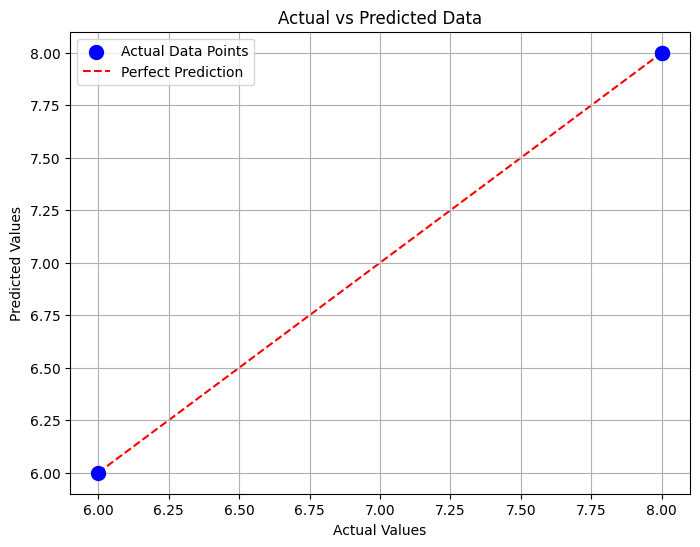

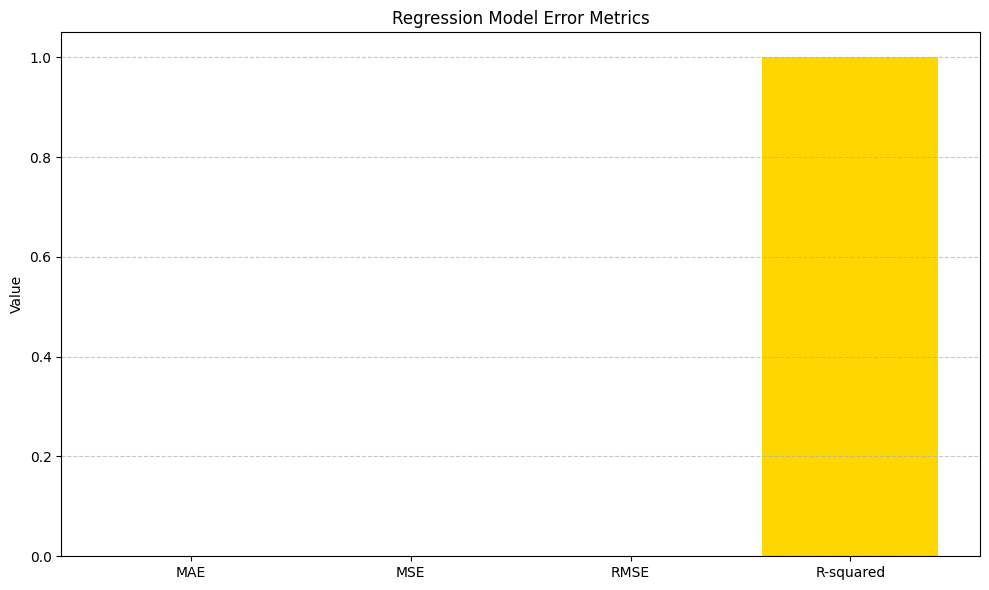

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Input data
x1 = np.array([1, 1, 2])
x2 = np.array([1, 2, 2])
y = np.array([6, 8, 8])

# Design matrix (adding bias term)
X = np.column_stack((np.ones(len(x1)), x1, x2))

# Matrix factorization (Normal Equation)
# theta = (XᵀX)^(-1) Xᵀy
theta = np.linalg.inv(X.T @ X) @ X.T @ y

# Extract coefficients
intercept = theta[0]
coef_x1 = theta[1]
coef_x2 = theta[2]

print("Regression Equation:")
print(f"y = {intercept:.2f} + {coef_x1:.2f}x1 + {coef_x2:.2f}x2")

# Predictions
y_pred = X @ theta

print("\nPredicted y-values:")
print(y_pred)

# Performance metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# Calculate Adjusted R-squared
n = len(y) # Number of observations
p = X.shape[1] - 1 # Number of predictors (excluding the intercept)

if (n - p - 1) > 0:
    adjusted_r_squared = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
else:
    adjusted_r_squared = np.nan # Or handle as appropriate for the data size

print("\nPerformance Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"Adj R² : {adjusted_r_squared:.4f}")

# -------------------- PLOTS --------------------

# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', s=100, label='Actual Data Points', zorder=2) # Made points larger and blue
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', label='Perfect Prediction', zorder=1) # Add a diagonal line for perfect prediction
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Data")
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Error Metrics (single bar graph)
metrics_names = ['MAE', 'MSE', 'RMSE', 'R-squared']
metrics_values = [mae, mse, rmse, r2]

# Only include Adjusted R-squared if it's not NaN
if not np.isnan(adjusted_r_squared):
    metrics_names.append('Adjusted R-squared')
    metrics_values.append(adjusted_r_squared)

plt.figure(figsize=(10, 6))
plt.bar(metrics_names, metrics_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'darkorange'])
plt.ylabel('Value')
plt.title('Regression Model Error Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()